# Notebook 1 — Data Pipeline

## Satellite Image Land-Use Classification & Temporal Change Detection

This notebook establishes the foundation for the satellite image analysis
pipeline by preparing and organizing the required datasets.

The data pipeline focuses on transforming raw satellite imagery into a
structured format suitable for deep learning models. It includes dataset
preparation, preprocessing, visualization, and creation of reliable data splits
for training and evaluation.

The objective of this stage is to ensure that the model receives consistent
and meaningful input while reducing the risk of data leakage during evaluation.


## Objective

Download EuroSAT, look at the class distribution and some sample tiles, and
build a **spatial block train/val/test split** (70% / 15% / 15%) so later
notebooks can reuse the same, reproducible split.

# Import Required Libraries

This section imports the essential Python libraries required for the data
pipeline implementation.

The libraries are used for:

- Numerical operations and array manipulation using NumPy
- Data visualization using Matplotlib
- Deep learning operations using PyTorch
- Dataset loading, preprocessing, and batching using Torchvision
- Creating efficient data pipelines using DataLoader and dataset subsets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

## Implementation

### Load the dataset

`torchvision.datasets.EuroSAT` downloads the official EuroSAT RGB dataset
(27,000 images, 10 classes) automatically and loads it the same way as
`ImageFolder`, so we don't need a custom Dataset class.

In [ ]:
raw_dataset = datasets.EuroSAT(root="./data", download=True)

class_names = raw_dataset.classes
print("Classes:", class_names)
print("Total images:", len(raw_dataset))

100%|██████████| 94.3M/94.3M [00:01<00:00, 86.9MB/s]


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


# Dataset Class Distribution Visualization

This section analyzes the distribution of images across different land-use
classes in the EuroSAT dataset.

Understanding class distribution helps identify whether the dataset is balanced
or if certain classes contain significantly more or fewer samples, which can
affect model training and evaluation performance.

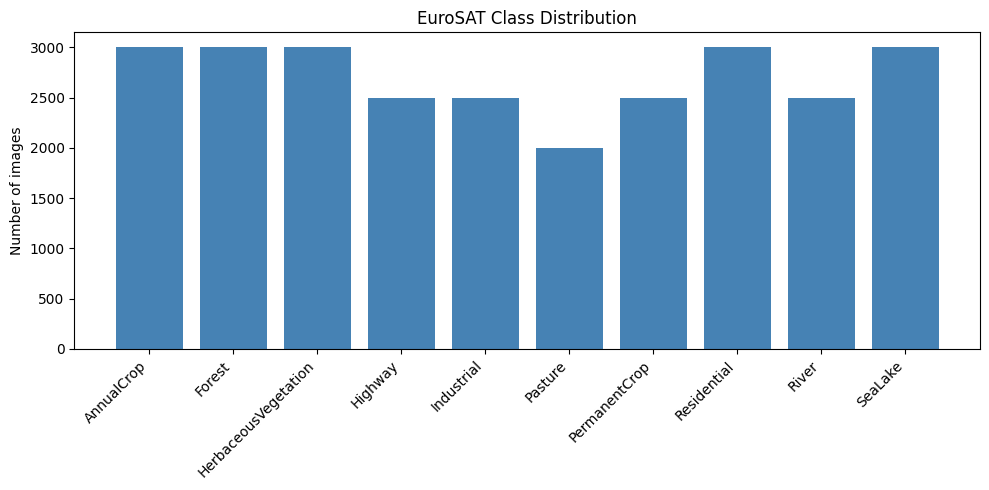

In [ ]:
labels = np.array(raw_dataset.targets)
counts = [np.sum(labels == i) for i in range(len(class_names))]

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("EuroSAT Class Distribution")
plt.tight_layout()
plt.show()

# Sample Image Visualization Across Classes

This section displays representative samples from each EuroSAT land-use class.

Visualizing images from every class helps verify that the dataset has been
loaded correctly and provides an understanding of the visual characteristics
and differences between various satellite image categories.

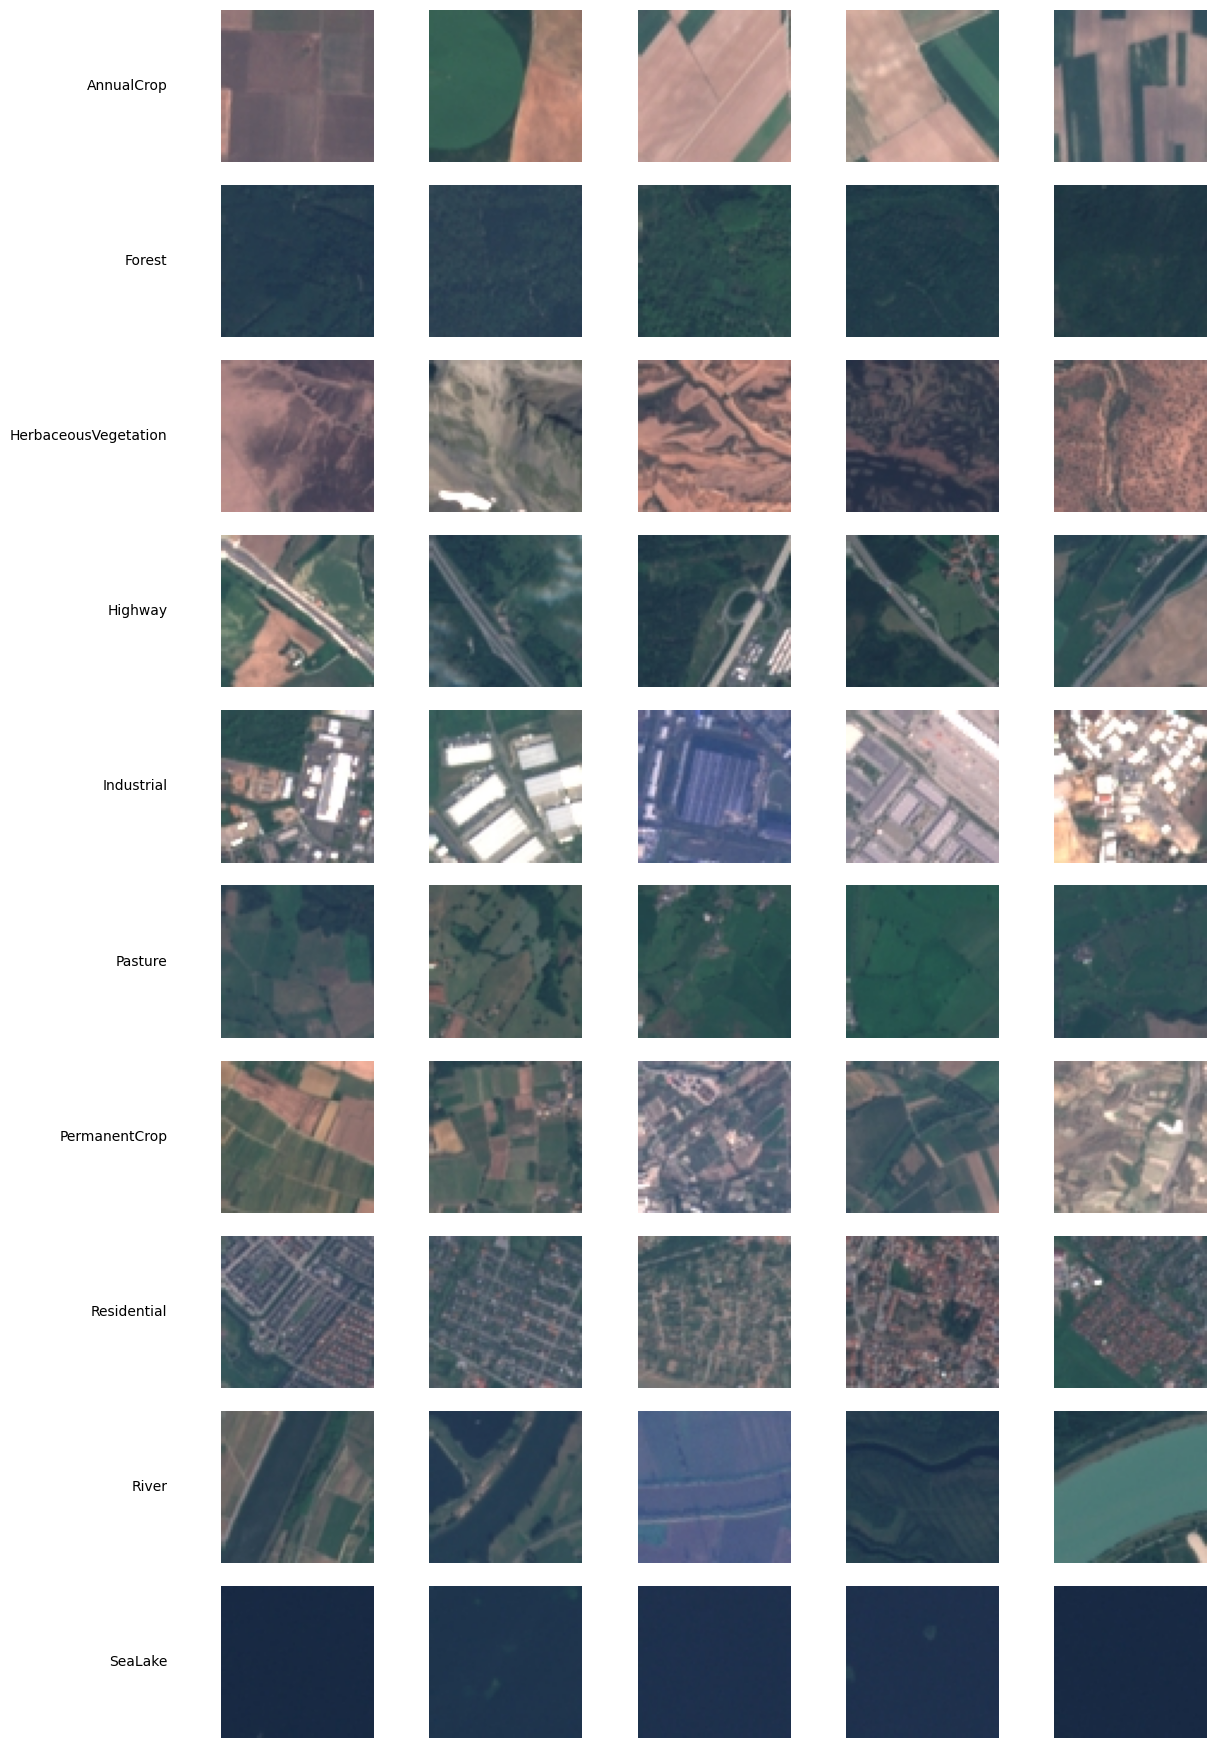

In [ ]:
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 1.8 * len(class_names)))

for class_idx, class_name in enumerate(class_names):
    class_indices = [i for i, label in enumerate(raw_dataset.targets) if label == class_idx]
    sample_indices = class_indices[:5]

    for col, img_idx in enumerate(sample_indices):
        image, _ = raw_dataset[img_idx]
        axes[class_idx, col].imshow(image)
        axes[class_idx, col].axis("off")

    axes[class_idx, 0].text(
        -0.35,
        0.5,
        class_name,
        transform=axes[class_idx, 0].transAxes,
        fontsize=10,
        va="center",
        ha="right"
    )

plt.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.98,
    bottom=0.02,
    wspace=0.05,
    hspace=0.15
)

plt.show()

### Spatial block train/val/test split (approximation)

The standard EuroSAT release has no geographic coordinates for each tile, so we
approximate a spatial block split:

1. Within each class, keep images in their **original dataset order** (assumed
   to roughly correspond to nearby, contiguous samples).
2. Split each class into **contiguous chunks**: first 70% → train, next 15% →
   val, last 15% → test. No shuffling — shuffling would destroy any spatial
   contiguity and defeat the purpose of a spatial block split.
3. This is done **per class** so every split still contains all 10 classes.

This same code will be repeated (unchanged) at the top of every later notebook,
so all notebooks use the identical split without needing to save/load files
between Colab sessions.

In [ ]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# remaining ~15% goes to test

train_indices, val_indices, test_indices = [], [], []

for class_idx in range(len(class_names)):
    class_indices = [i for i, label in enumerate(raw_dataset.targets) if label == class_idx]
    n = len(class_indices)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    train_indices.extend(class_indices[:train_end])
    val_indices.extend(class_indices[train_end:val_end])
    test_indices.extend(class_indices[val_end:])

print("Train size:", len(train_indices))
print("Val size:  ", len(val_indices))
print("Test size: ", len(test_indices))

Train size: 18900
Val size:   4050
Test size:  4050


### Build DataLoaders

The dataset is prepared for model training by applying the required
preprocessing steps:

- Images are resized to 64×64 pixels, which matches the native resolution of
  the EuroSAT dataset.
- Images are converted into PyTorch tensors.
- Pixel values are normalized to improve training stability.

The same transformation pipeline is applied to the training, validation, and
test splits to ensure consistent input representation.

No data augmentation is applied, as it is not specified in the project
requirements.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

dataset = datasets.EuroSAT(root="./data", download=True, transform=transform)

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify DataLoaders

This section verifies that the train, validation, and test DataLoaders have
been created correctly.

The checks include:

- Number of batches available in each split
- Shape of a sample input batch
- Shape of the corresponding labels

This ensures that the images and labels are correctly formatted and ready for
model training.

In [ ]:
print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

images, labels_batch = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)

Train batches: 591
Val batches:   127
Test batches:  127
Batch image shape: torch.Size([32, 3, 64, 64])
Batch label shape: torch.Size([32])


## Conclusion

- Loaded the EuroSAT dataset automatically with 10 land-use classes and
  27,000 satellite images.
- Explored the dataset through class distribution analysis and sample image
  visualization.
- Created an approximate spatial block split (70/15/15) by keeping grouped
  samples together instead of applying a fully random split, helping reduce
  potential spatial leakage.
- Prepared `train_loader`, `val_loader`, and `test_loader` for the upcoming
  model training experiments in Notebook 2.